In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import time

from urllib.parse import urljoin, urlparse, urldefrag

In [2]:
clubs = {
    "Arsenal": "https://en.wikipedia.org/wiki/Arsenal_F.C.",
    "Chelsea": "https://en.wikipedia.org/wiki/Chelsea_F.C.",
    "Tottenham Hotspur": "https://en.wikipedia.org/wiki/Tottenham_Hotspur_F.C.",
    "Manchester United": "https://en.wikipedia.org/wiki/Manchester_United_F.C.",
    "Manchester City": "https://en.wikipedia.org/wiki/Manchester_City_F.C.",
    "Liverpool": "https://en.wikipedia.org/wiki/Liverpool_F.C.",
    "Everton": "https://en.wikipedia.org/wiki/Everton_F.C.",
    "Leeds United": "https://en.wikipedia.org/wiki/Leeds_United_F.C.",
    "Newcastle United": "https://en.wikipedia.org/wiki/Newcastle_United_F.C.",
    "Sunderland": "https://en.wikipedia.org/wiki/Sunderland_A.F.C.",
    "Aston Villa": "https://en.wikipedia.org/wiki/Aston_Villa_F.C.",
    "Birmingham City": "https://en.wikipedia.org/wiki/Birmingham_City_F.C."
}

In [3]:
path_to_club = {}

for club, url in clubs.items():
    path = urlparse(url).path
    path_to_club[path] = club

path_to_club

{'/wiki/Arsenal_F.C.': 'Arsenal',
 '/wiki/Chelsea_F.C.': 'Chelsea',
 '/wiki/Tottenham_Hotspur_F.C.': 'Tottenham Hotspur',
 '/wiki/Manchester_United_F.C.': 'Manchester United',
 '/wiki/Manchester_City_F.C.': 'Manchester City',
 '/wiki/Liverpool_F.C.': 'Liverpool',
 '/wiki/Everton_F.C.': 'Everton',
 '/wiki/Leeds_United_F.C.': 'Leeds United',
 '/wiki/Newcastle_United_F.C.': 'Newcastle United',
 '/wiki/Sunderland_A.F.C.': 'Sunderland',
 '/wiki/Aston_Villa_F.C.': 'Aston Villa',
 '/wiki/Birmingham_City_F.C.': 'Birmingham City'}

In [4]:
links = []

headers = {
    "User-Agent": "INST414 student network analysis project"
}

for source_club, source_url in clubs.items():

    response = requests.get(
        source_url,
        headers=headers
    )

    print(source_club, response.status_code)

    if response.status_code != 200:
        continue

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    rivalry_heading = None

    # Find a heading containing the word rivalry/rivalries
    for heading in soup.find_all(["h2", "h3"]):

        heading_text = heading.get_text(
            " ",
            strip=True
        ).lower()

        if "rivalr" in heading_text:
            rivalry_heading = heading
            break

    if rivalry_heading is None:
        print("  No rivalry section found")
        continue

    # Collect content until the next major section
    current = rivalry_heading.parent

    while current is not None:

        current = current.find_next_sibling()

        if current is None:
            break

        # Stop when a new H2 section begins
        if current.find("h2"):
            break

        for tag in current.find_all(
            "a",
            href=True
        ):

            target_url = urljoin(
                source_url,
                tag["href"]
            )

            target_url = urldefrag(
                target_url
            )[0]

            target_path = urlparse(
                target_url
            ).path

            if target_path in path_to_club:

                target_club = path_to_club[
                    target_path
                ]

                if source_club != target_club:

                    links.append({
                        "source_club": source_club,
                        "source_url": source_url,
                        "target_club": target_club,
                        "target_url": target_url
                    })

    time.sleep(1)

Arsenal 200
Chelsea 200
Tottenham Hotspur 200
Manchester United 200
Manchester City 200
Liverpool 200
Everton 200
Leeds United 200
Newcastle United 200
Sunderland 200
Aston Villa 200
Birmingham City 200
  No rivalry section found


In [5]:
links_df = pd.DataFrame(links)

links_df = links_df.drop_duplicates(
    subset=[
        "source_club",
        "target_club"
    ]
)

print(
    "Number of rivalry hyperlinks:",
    len(links_df)
)

links_df

Number of rivalry hyperlinks: 22


,source_club,source_url,target_club,target_url
0,Arsenal,https://en.wikipedia.org/wiki/Arsenal_F.C.,Tottenham Hotspur,https://en.wikipedia.org/wiki/Tottenham_Hotspu...
1,Arsenal,https://en.wikipedia.org/wiki/Arsenal_F.C.,Chelsea,https://en.wikipedia.org/wiki/Chelsea_F.C.
2,Chelsea,https://en.wikipedia.org/wiki/Chelsea_F.C.,Arsenal,https://en.wikipedia.org/wiki/Arsenal_F.C.
3,Chelsea,https://en.wikipedia.org/wiki/Chelsea_F.C.,Tottenham Hotspur,https://en.wikipedia.org/wiki/Tottenham_Hotspu...
4,Chelsea,https://en.wikipedia.org/wiki/Chelsea_F.C.,Liverpool,https://en.wikipedia.org/wiki/Liverpool_F.C.
5,Chelsea,https://en.wikipedia.org/wiki/Chelsea_F.C.,Manchester United,https://en.wikipedia.org/wiki/Manchester_Unite...
6,Tottenham Hotspur,https://en.wikipedia.org/wiki/Tottenham_Hotspu...,Arsenal,https://en.wikipedia.org/wiki/Arsenal_F.C.
7,Tottenham Hotspur,https://en.wikipedia.org/wiki/Tottenham_Hotspu...,Chelsea,https://en.wikipedia.org/wiki/Chelsea_F.C.
8,Manchester United,https://en.wikipedia.org/wiki/Manchester_Unite...,Liverpool,https://en.wikipedia.org/wiki/Liverpool_F.C.
9,Manchester United,https://en.wikipedia.org/wiki/Manchester_Unite...,Manchester City,https://en.wikipedia.org/wiki/Manchester_City_...


In [6]:
links_df.to_csv(
    "soccer_rivalry_links.csv",
    index=False
)

print("Dataset saved.")

Dataset saved.


In [7]:
g = nx.DiGraph()

for club in clubs:
    g.add_node(club)

for _, row in links_df.iterrows():

    g.add_edge(
        row["source_club"],
        row["target_club"]
    )

print(
    "Nodes:",
    g.number_of_nodes()
)

print(
    "Edges:",
    g.number_of_edges()
)

print(
    "Density:",
    nx.density(g)
)

Nodes: 12
Edges: 22
Density: 0.16666666666666666


In [8]:
for club in g.nodes:

    print(
        club,
        "in:",
        g.in_degree(club),
        "out:",
        g.out_degree(club)
    )

Arsenal in: 4 out: 2
Chelsea in: 4 out: 4
Tottenham Hotspur in: 3 out: 2
Manchester United in: 3 out: 5
Manchester City in: 1 out: 5
Liverpool in: 4 out: 1
Everton in: 0 out: 1
Leeds United in: 1 out: 0
Newcastle United in: 1 out: 1
Sunderland in: 1 out: 1
Aston Villa in: 0 out: 0
Birmingham City in: 0 out: 0


In [9]:
in_degree = nx.in_degree_centrality(g)

betweenness = nx.betweenness_centrality(g)

pagerank = nx.pagerank(g)

In [10]:
print(
    "Top Clubs by In-Degree Centrality"
)

for club in sorted(
    in_degree,
    key=in_degree.get,
    reverse=True
):

    print(
        club,
        in_degree[club]
    )

Top Clubs by In-Degree Centrality
Arsenal 0.36363636363636365
Chelsea 0.36363636363636365
Liverpool 0.36363636363636365
Tottenham Hotspur 0.2727272727272727
Manchester United 0.2727272727272727
Manchester City 0.09090909090909091
Leeds United 0.09090909090909091
Newcastle United 0.09090909090909091
Sunderland 0.09090909090909091
Everton 0.0
Aston Villa 0.0
Birmingham City 0.0


In [11]:
print(
    "Top Clubs by Betweenness Centrality"
)

for club in sorted(
    betweenness,
    key=betweenness.get,
    reverse=True
):

    print(
        club,
        betweenness[club]
    )

Top Clubs by Betweenness Centrality
Manchester United 0.15454545454545454
Chelsea 0.08181818181818183
Liverpool 0.054545454545454536
Arsenal 0.00909090909090909
Manchester City 0.00909090909090909
Tottenham Hotspur 0.0
Everton 0.0
Leeds United 0.0
Newcastle United 0.0
Sunderland 0.0
Aston Villa 0.0
Birmingham City 0.0


In [12]:
print(
    "Top Clubs by PageRank"
)

for club in sorted(
    pagerank,
    key=pagerank.get,
    reverse=True
):

    print(
        club,
        pagerank[club]
    )

Top Clubs by PageRank
Chelsea 0.15012977860866988
Manchester United 0.1383400294589158
Arsenal 0.12774188617720142
Newcastle United 0.11990836439431073
Sunderland 0.11990836439431073
Tottenham Hotspur 0.11123808806509633
Liverpool 0.09575549834346593
Manchester City 0.041506377960965846
Leeds United 0.041506377960965846
Everton 0.01798841154536583
Aston Villa 0.01798841154536583
Birmingham City 0.01798841154536583


In [13]:
results = pd.DataFrame({
    "Club": list(g.nodes),

    "In-Degree Centrality": [
        in_degree[club]
        for club in g.nodes
    ],

    "Betweenness Centrality": [
        betweenness[club]
        for club in g.nodes
    ],

    "PageRank": [
        pagerank[club]
        for club in g.nodes
    ]
})

results = results.sort_values(
    "PageRank",
    ascending=False
)

results

,Club,In-Degree Centrality,Betweenness Centrality,PageRank
1,Chelsea,0.363636,0.081818,0.150130
3,Manchester United,0.272727,0.154545,0.138340
0,Arsenal,0.363636,0.009091,0.127742
9,Sunderland,0.090909,0.000000,0.119908
8,Newcastle United,0.090909,0.000000,0.119908
2,Tottenham Hotspur,0.272727,0.000000,0.111238
5,Liverpool,0.363636,0.054545,0.095755
4,Manchester City,0.090909,0.009091,0.041506
7,Leeds United,0.090909,0.000000,0.041506
6,Everton,0.000000,0.000000,0.017988


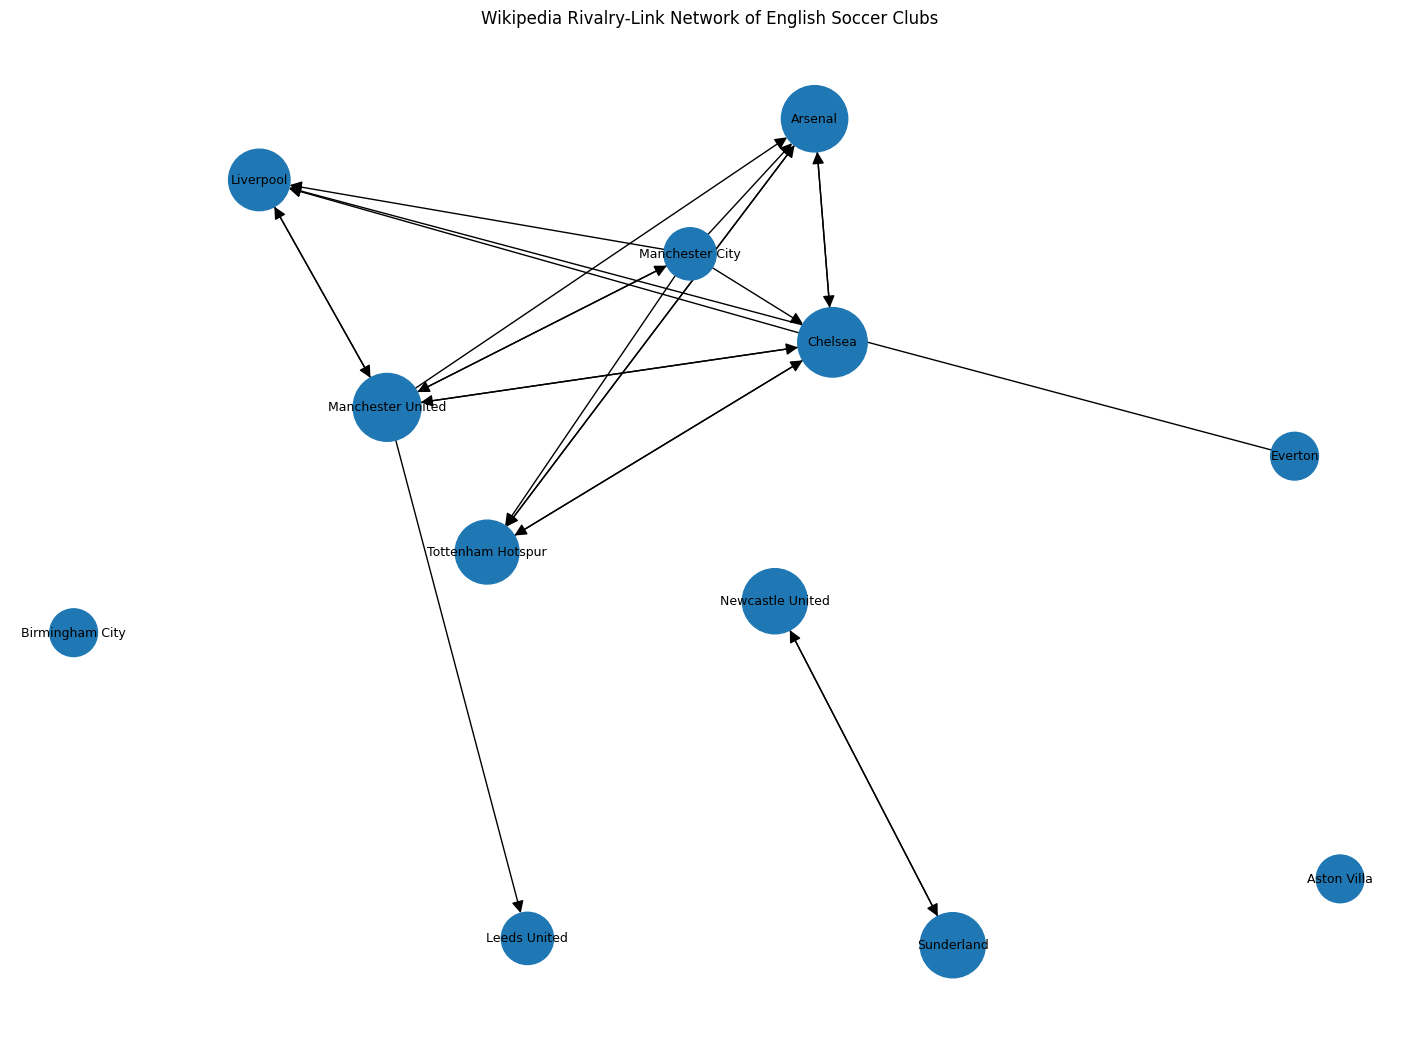

In [14]:
plt.figure(
    figsize=(14, 10)
)

pos = nx.spring_layout(
    g,
    seed=42,
    k=1.4
)

node_sizes = [
    1000 + pagerank[club] * 10000
    for club in g.nodes
]

nx.draw(
    g,
    pos,
    with_labels=True,
    node_size=node_sizes,
    font_size=9,
    arrows=True,
    arrowsize=18
)

plt.title(
    "Wikipedia Rivalry-Link Network of English Soccer Clubs"
)

plt.savefig(
    "soccer_rivalry_network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

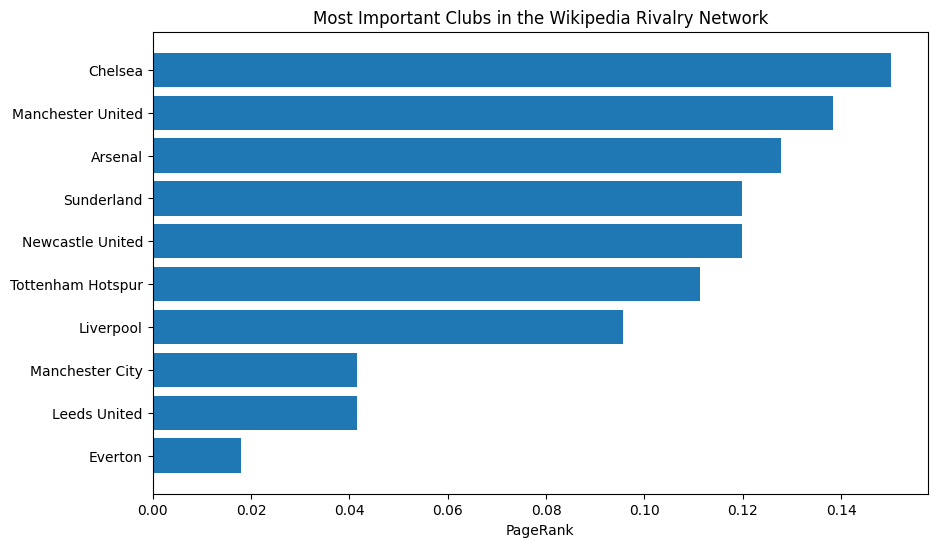

In [15]:
top10 = results.head(10)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    top10["Club"],
    top10["PageRank"]
)

plt.xlabel(
    "PageRank"
)

plt.title(
    "Most Important Clubs in the Wikipedia Rivalry Network"
)

plt.gca().invert_yaxis()

plt.savefig(
    "soccer_rivalry_pagerank.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
results[
    [
        "Club",
        "In-Degree Centrality",
        "Betweenness Centrality",
        "PageRank"
    ]
].head(3)

,Club,In-Degree Centrality,Betweenness Centrality,PageRank
1,Chelsea,0.363636,0.081818,0.150130
3,Manchester United,0.272727,0.154545,0.138340
0,Arsenal,0.363636,0.009091,0.127742


In [17]:
results.to_csv(
    "soccer_rivalry_results.csv",
    index=False
)

print("Results saved.")

Results saved.
